# Influence horizon: the one number that explains content-defined chunking

**Definition.** Take any scheme that reads a stream and produces a hash state (or a boundary
decision) at each position. Its **influence horizon** is the largest distance `d` such that
changing the input `d` positions back can still change the current state.

That one number answers the questions the other notebooks keep circling:

- *Why do edits heal?* Because past the horizon, the state is computed from identical input —
  so every later decision is identical. **Healing distance ≈ horizon** (measured in §2).
- *Why can't an accumulating hash chunk a stream?* Its horizon is infinite — one edit
  re-randomizes every later decision. **Infinite horizon = no healing** (measured in §3).
- *Why does fixed-size chunking not heal either?* Its "decision" ignores content entirely —
  there is nothing to re-lock onto. The two failure poles bracket the design space.
- *Why does per-element chunking need no window?* Its horizon is **exactly one item, by
  construction** — the item boundary does the window's job for free (§4).

The [hashes notebook](boundary_hashes.ipynb) introduced the horizon as a table; this one earns
it as a concept: profile it, connect it causally to healing, break it at both poles, and then
use it to explain the per-element / rolling split properly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import prolly_chunking as pc

plt.rcParams.update({"figure.figsize": (7.5, 3.2), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
rng = np.random.default_rng(1)
print("ready")

ready


## 1. The defining experiment: the horizon profile

Flip one input bit at distance `d` before the point where the state is read; repeat over random
streams; plot the fraction of trials where the state changed. Every scheme draws a curve — its
**horizon profile** — and the profile is the scheme's signature:

- **FNV-1a** (accumulator): every per-byte round is a bijection, so any flip anywhere changes
  the final state. A flat line at 100% — horizon ∞.
- **buzhash, W = 67**: a byte's term is XORed out exactly when it leaves the window buffer. A
  cliff at exactly 67.
- **gear**: a flip's state-difference doubles each step (`delta << 1 mod 2^32`) and falls off
  the top after 32 shifts. A cliff at exactly 32, with a shoulder (which bit you flip decides
  how early it exits).
- **gear masked to its low 13 bits**: bit `j` sees only the last `j+1` bytes, so the mask width
  *is* the horizon. A cliff at 13.

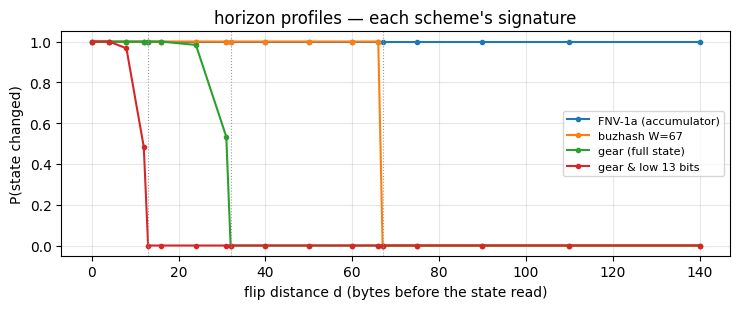

cliffs measured exactly where the algebra says: 13, 32, 67 — and FNV never forgets


In [2]:
GEAR = [int(x) for x in np.random.default_rng(99).integers(0, 2**32, size=256, dtype=np.uint64)]

def fnv_state(data):
    return pc.fnv1a(data)

def buz_state(data):
    bz = pc.BuzHash(pc.PROD_WINDOW)
    for b in data:
        bz.hash_byte(b)
    return bz.sum32()

def gear_state(data):
    h = 0
    for b in data:
        h = ((h << 1) + GEAR[b]) & 0xFFFFFFFF
    return h

def gear_low13(data):
    return gear_state(data) & 0x1FFF

def change_rate(state_fn, d, trials=60, length=160):
    changed = 0
    for _ in range(trials):
        buf = bytearray(rng.integers(0, 256, size=length, dtype=np.uint8).tobytes())
        base = state_fn(bytes(buf))
        buf[length - 1 - d] ^= 1 << int(rng.integers(0, 8))
        changed += state_fn(bytes(buf)) != base
    return changed / trials

ds = np.array([0, 4, 8, 12, 13, 16, 24, 31, 32, 40, 50, 60, 66, 67, 75, 90, 110, 140])
schemes = [("FNV-1a (accumulator)", fnv_state), ("buzhash W=67", buz_state),
           ("gear (full state)", gear_state), ("gear & low 13 bits", gear_low13)]
profiles = {name: [change_rate(fn, int(d)) for d in ds] for name, fn in schemes}

for name, prof in profiles.items():
    plt.plot(ds, prof, marker="o", ms=3, label=name)
for x, c in [(13, "#999"), (32, "#999"), (67, "#999")]:
    plt.axvline(x, color=c, ls=":", lw=0.8)
plt.xlabel("flip distance d (bytes before the state read)")
plt.ylabel("P(state changed)")
plt.title("horizon profiles — each scheme's signature")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

assert profiles["FNV-1a (accumulator)"][-1] == 1.0            # never forgets
assert profiles["buzhash W=67"][ds.tolist().index(66)] == 1.0
assert profiles["buzhash W=67"][ds.tolist().index(67)] == 0.0  # the cliff, exactly
assert profiles["gear (full state)"][ds.tolist().index(32)] == 0.0
assert profiles["gear & low 13 bits"][ds.tolist().index(13)] == 0.0
print("cliffs measured exactly where the algebra says: 13, 32, 67 — and FNV never forgets")

## 2. The horizon is the healing knob — causally, not by analogy

The first notebook showed one insertion healing within ~W. The claim worth owning is stronger:
**the horizon *sets* the healing distance**. After an insertion, boundary decisions are wrong
only while the inserted byte is inside the horizon; the first *natural* boundary after it clears
re-locks everything. So healing ≈ horizon + the expected wait for the next natural cut
(≈ target size). Sweep W and watch the median healing distance track it:

In [3]:
data = np.random.default_rng(7).integers(0, 256, size=6000, dtype=np.uint8).tobytes()
offsets = range(500, 5501, 125)                      # 41 insertion sites

print(f"{'W':>5} {'median heal (B)':>16} {'p90':>6} {'median − W':>11}   (mask 6 → target 64)")
medians = {}
for W in (16, 48, 128):
    resyncs = [r for r, _ in (pc.healing_distance(data, off, window=W, mask_bits=6)
                              for off in offsets) if r is not None]
    med = float(np.median(resyncs))
    medians[W] = med
    print(f"{W:>5} {med:>16.0f} {np.percentile(resyncs, 90):>6.0f} {med - W:>11.0f}")

assert medians[16] < medians[48] < medians[128]      # healing tracks the horizon, monotonically
print("\n→ the horizon sets the floor; the mask adds the wait for the next natural boundary.")
print("  W is not the chunk size — it is HOW FAR AN EDIT REACHES. That is what you tune.")

    W  median heal (B)    p90  median − W   (mask 6 → target 64)


   16               55    118          39


   48               88    205          40


  128              182    360          54

→ the horizon sets the floor; the mask adds the wait for the next natural boundary.
  W is not the chunk size — it is HOW FAR AN EDIT REACHES. That is what you tune.


## 3. Breaking it at both poles

Two degenerate horizons, one healthy one. Insert a single byte mid-stream and measure how many
downstream boundaries recover — over **many** random insertion sites and bytes, because a single
trial lies here in a fascinating way (below):

- **Infinite horizon** — an FNV *accumulator* used as a stream chunker (mask its running state
  at every byte). The boundary test reads the low-k lane, and each lane round is a *bijection* —
  so the edited and original lane orbits, once different, can **never merge**. Downstream
  boundaries overlap only by coincidence… with one exception: if the inserted byte's round
  happens to map the current lane state to itself (a fixed point, odds ≈ 1/2^k per insertion),
  the lane never diverges at all and recovery is instantly 100%. An accumulator doesn't heal —
  it either coincides, or got lucky *at the moment of the edit*. (The first draft of this cell
  ran one trial, hit the fixed-point fluke, and "measured" 100% — the distribution is the honest
  instrument.)
- **No content horizon** — fixed-size chunking: decisions depend on *position*, every position
  shifted, nothing to re-lock onto. Exactly 0%, every time.
- **Bounded horizon** — the rolling window: everything past `W + one chunk` heals, every time.

In [4]:
def recovery(data, boundaries_fn, insert_at, byte):
    edited = data[:insert_at] + bytes([byte]) + data[insert_at:]
    orig = {x for x in boundaries_fn(data) if x > insert_at}
    shifted = {x - 1 for x in boundaries_fn(edited) if x > insert_at}
    return len(orig & shifted) / len(orig) if orig else 1.0

def fnv_accumulator_boundaries(data, k=6):
    mask = (1 << k) - 1
    h, out = 0x811C9DC5, []
    for i, b in enumerate(data):
        h = ((h ^ b) * 0x01000193) & 0xFFFFFFFF
        if (h & mask) == 0:
            out.append(i)
    return out

def fixed_size_boundaries(data, size=64):
    return list(range(size, len(data), size))

def rolling_boundaries(data):
    return pc.toy_buzhash_boundaries(data, window=48, mask_bits=6)

TRIALS = [(int(rng.integers(500, 4500)), int(rng.integers(0, 256))) for _ in range(48)]
print(f"{'scheme':>28} {'horizon':>10} {'median':>7} {'mean':>6} {'100% flukes':>12}")
for name, horizon, fn in [
        ("FNV accumulator over stream", "infinite", fnv_accumulator_boundaries),
        ("fixed-size 64 B", "no content", fixed_size_boundaries),
        ("rolling window W=48", "48 B", rolling_boundaries)]:
    rs = np.array([recovery(data, fn, pos, b) for pos, b in TRIALS])
    print(f"{name:>28} {horizon:>10} {np.median(rs):>7.0%} {rs.mean():>6.0%} "
          f"{int((rs == 1.0).sum()):>7d}/{len(rs)}")

print("\n→ the accumulator's median recovery is coincidence-level; its rare 100% runs are")
print("  the lane fixed-point fluke (odds ≈ 1/64 per edit) — luck at edit time, not healing.")
print("  Fixed-size never recovers; the window recovers essentially everything, every time.")

                      scheme    horizon  median   mean  100% flukes
 FNV accumulator over stream   infinite      0%     2%       1/48
             fixed-size 64 B no content      0%     0%       0/48


         rolling window W=48       48 B     98%    98%      20/48

→ the accumulator's median recovery is coincidence-level; its rare 100% runs are
  the lane fixed-point fluke (odds ≈ 1/64 per edit) — luck at edit time, not healing.
  Fixed-size never recovers; the window recovers essentially everything, every time.


## 4. Supplement: why per-element checking needs no window

The rolling window can look like the *essence* of content-defined chunking. It isn't — it's a
*workaround*. The essence is a bounded content horizon, and there are two ways to get one:

**If the stream already has items, the item is the horizon.** Per-element chunking decides at
item granularity: `boundary(item) = mask(H(item))`, each item hashed *whole*. The decision
depends on that item's bytes and nothing else — horizon = exactly one item, by construction.
There is nothing to roll because there is nothing to forget: the item boundary already tells you
where influence starts and stops. Any hash works (that is why plain FNV suffices), edits are
perfectly local, and the window machinery — buffer, rotation, removal, W-tuning — simply does
not exist.

**If the stream has no items, the window *manufactures* a horizon.** Raw bytes carry no
structure that says where influence should stop, so the rolling hash imposes one: "the last W
bytes." That is the entire job of the window — it is a synthetic item boundary, paid for with
per-byte machinery and a tunable-but-arbitrary W.

The trade, stated once:

| | per-element | rolling window |
|---|---|---|
| horizon | 1 item, exact, free | W bytes, tunable, needs machinery |
| requires | pre-existing item structure | nothing — works on raw bytes |
| chunk-size control | in **items** (bytes drift with item sizes) | in **bytes**, directly |
| healing | automatic and perfect (≤ the item's own chunk) | ≈ W + one chunk (§2) |
| hash constraints | any fair hash, applied whole | must roll (or forget structurally, like gear) |

Measure the per-element horizon profile — in *item* units this time. It is the sharpest curve
possible: distance 0 means "the item itself", and everything else is exactly zero:

In [5]:
def decision_change_rate(d, trials=400):
    changed = 0
    for _ in range(trials):
        items = [int(x) for x in rng.integers(0, 2**32, size=d + 1, dtype=np.uint64)]
        base_last = pc.is_boundary(items[-1], 3)
        items[0] ^= 1 << int(rng.integers(0, 32))        # mutate the item d back
        changed += pc.is_boundary(items[-1], 3) != base_last if d > 0 else \
                   pc.is_boundary(items[0], 3) != base_last
    return changed / trials

print("per-element horizon profile (distance in ITEMS, fresh random items per trial):")
for d in (0, 1, 2, 10, 100):
    r = decision_change_rate(d)
    print(f"  d = {d:3d} items:  decision change rate {r:4.0%}")
p = 1 / 8
visible = 12 / 32          # the sealed lane: a low-3-bit decision only sees bits 0-2 of each byte
expected = visible * 2 * p * (1 - p)
print(f"\n→ d=0: the sealed lane cuts both ways — bits 3-7 of every byte are INVISIBLE to a")
print(f"  low-3-bit decision, so only 12 of 32 possible bit-flips can matter at all:")
print(f"  expected rate = (12/32) · 2p(1−p) = {expected:.0%}  (matches the measurement)")
print("  every d>0 is EXACTLY zero — no other item can ever be implicated")

per-element horizon profile (distance in ITEMS, fresh random items per trial):
  d =   0 items:  decision change rate   8%
  d =   1 items:  decision change rate   0%
  d =   2 items:  decision change rate   0%
  d =  10 items:  decision change rate   0%
  d = 100 items:  decision change rate   0%

→ d=0: the sealed lane cuts both ways — bits 3-7 of every byte are INVISIBLE to a
  low-3-bit decision, so only 12 of 32 possible bit-flips can matter at all:
  expected rate = (12/32) · 2p(1−p) = 8%  (matches the measurement)
  every d>0 is EXACTLY zero — no other item can ever be implicated


**And production is deliberately both.** The engine's entries are real items (key/value byte
segments), but their *sizes vary* — so per-element probability alone would give poor control of
chunk size in bytes. The splitter therefore rolls a W=67 window over the serialized entry bytes
(byte-denominated geometry: the staircase targets ~4 KiB of *bytes*), while `crossedBoundary` is
consulted only **between entries** (cuts land on item edges — no torn entries). Horizon in
bytes, alignment in items:

In [6]:
corpus = pc.sha256_counter_stream(200_000)
ends = pc.chunk_end_offsets(corpus, level=0, entry_size=32)
sizes = np.diff([0] + ends)

assert all(e % 32 == 0 for e in ends)                 # every cut on an entry edge
assert all(pc.PROD_MIN_CHUNK <= s <= pc.PROD_CERTAIN_CUT for s in sizes)
print(f"{len(ends)} chunks from 32-byte entries: every end ≡ 0 (mod 32)  ✓")
print(f"sizes stay in the staircase envelope [{pc.PROD_MIN_CHUNK}, {pc.PROD_CERTAIN_CUT}]  ✓")
print("→ byte-denominated geometry, item-aligned cuts: the window buys the first,")
print("  the between-entries consultation preserves the second")

43 chunks from 32-byte entries: every end ≡ 0 (mod 32)  ✓
sizes stay in the staircase envelope [512, 15360]  ✓
→ byte-denominated geometry, item-aligned cuts: the window buys the first,
  the between-entries consultation preserves the second


## Summary: one axis, five schemes

| scheme | horizon | heals? | needs | verdict |
|---|---|---|---|---|
| fixed-size | none (position, not content) | never | nothing | not content-defined at all |
| FNV accumulator on a stream | infinite | never | nothing | a hash, but not a chunker |
| **per-element** (hash items whole) | **exactly 1 item** | perfectly, automatically | item structure | right whenever items exist |
| **rolling window** (buzhash) | **exactly W bytes** | within ≈ W + one chunk | per-byte machinery | right for raw bytes; W is the knob |
| gear | ≤ state width (32) | within ≈ 32 + one chunk | almost nothing | a window you don't get to size |
| **production hybrid** | W bytes, item-aligned | yes | both | byte geometry *and* whole entries |

The horizon is not one property among many — it is the load-bearing one. "Content-defined"
means, precisely: *decisions are a function of a bounded neighborhood of content*. The window,
the per-element trick, and gear's shift-out are three implementations of that single idea; the
accumulator and fixed-size chunking are its two distinct negations.